In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium as fl
from folium.plugins import HeatMap

Função para criação de arquivo com a serie historica de focos de incendio


In [40]:
def serieHistorica (path, anos, totalFocosAno):

    arq = pd.read_csv(path, sep=",")

    totalFocos = arq.loc[arq["estado"] == "MINAS GERAIS"].shape[0]

    arq["data_pas"] = pd.to_datetime(arq["data_pas"])
    ano = arq["data_pas"].dt.year.mode()[0]

    anos.append(ano)
    totalFocosAno.append(totalFocos)

In [12]:
anos = []
totalFocos = []

pathArq = [
    "../data/raw/focos_br_ref_2025.csv",
    "../data/raw/focos_br_ref_2024.csv",
    "../data/raw/focos_br_ref_2023.csv",
    "../data/raw/focos_br_ref_2022.csv",
    "../data/raw/focos_br_ref_2021.csv",
    "../data/raw/focos_br_ref_2020.csv",
    "../data/raw/focos_br_ref_2019.csv",
    "../data/raw/focos_br_ref_2018.csv",
    "../data/raw/focos_br_ref_2017.csv",
    "../data/raw/focos_br_ref_2016.csv",
    "../data/raw/focos_br_ref_2015.csv"

]

for path in pathArq:
    serieHistorica(path, anos, totalFocos)

serie = pd.DataFrame({"Ano": anos, "Numero de Focos": totalFocos})

serie.to_csv("../data/processed/numero_focos_mg_ref_2015-2025.csv", sep=",")

serie.head()

,Ano,Numero de Focos
0,2025,8716
1,2024,11787
2,2023,6498
3,2022,7790
4,2021,12110


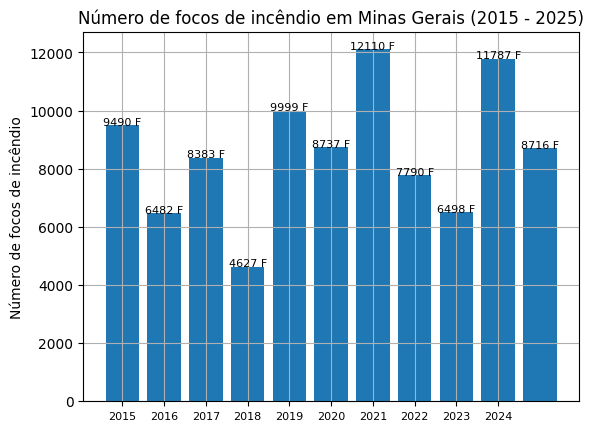

In [13]:
plt.Figure(figsize=(16,9))
plt.bar(serie["Ano"], serie["Numero de Focos"])
plt.ylabel("Número de focos de incêndio")
plt.xticks(np.arange(2015, 2025, 1), fontsize=8)
plt.grid(True)
for ano, value in zip(serie["Ano"], serie["Numero de Focos"]):
    plt.text(ano, value, f"{value} F", fontsize=8, ha="center")
plt.title("Número de focos de incêndio em Minas Gerais (2015 - 2025)")
plt.show()

In [14]:
pathArq = [
    "../data/raw/focos_br_ref_2025.csv",
    "../data/raw/focos_br_ref_2024.csv",
    "../data/raw/focos_br_ref_2023.csv",
    "../data/raw/focos_br_ref_2022.csv",
    "../data/raw/focos_br_ref_2021.csv",
    "../data/raw/focos_br_ref_2020.csv",
    "../data/raw/focos_br_ref_2019.csv",
    "../data/raw/focos_br_ref_2018.csv",
    "../data/raw/focos_br_ref_2017.csv",
    "../data/raw/focos_br_ref_2016.csv",
    "../data/raw/focos_br_ref_2015.csv"

]

dfList = []

for arq in pathArq:
    df = pd.read_csv(arq, sep=",")
    dfList.append(df)

dfTotal = pd.concat(dfList, ignore_index=True)

dfTotal = dfTotal.drop(["id_bdq", "foco_id", "pais"], axis=1)

dfTotal.head()

,lat,lon,data_pas,estado,municipio,bioma
0,-7.59931,-37.71227,2025-01-01 16:52:00,PERNAMBUCO,SOLIDÃO,Caatinga
1,-12.31740,-37.89132,2025-01-01 16:52:00,BAHIA,ENTRE RIOS,Mata Atlântica
2,-4.21420,-38.21260,2025-01-01 16:54:00,CEARÁ,BEBERIBE,Caatinga
3,-7.28188,-34.93212,2025-01-01 16:52:00,PARAÍBA,ALHANDRA,Mata Atlântica
4,-7.60073,-37.72230,2025-01-01 16:52:00,PERNAMBUCO,SOLIDÃO,Caatinga


In [15]:
dfTotal.to_csv("../data/raw/focos_br_ref_2015-2025.csv")


In [16]:
dataEstados = dfTotal["estado"].value_counts().reset_index()
dataEstados.columns = ["Estado", "Numero_Focos"]

dataEstados = dataEstados.sort_values("Numero_Focos", ascending = False)

dataEstados.head(10)

,Estado,Numero_Focos
0,PARÁ,393955
1,MATO GROSSO,317760
2,MARANHÃO,229624
3,AMAZONAS,162838
4,TOCANTINS,140215
5,PIAUÍ,118402
6,RONDÔNIA,111008
7,BAHIA,106858
8,MINAS GERAIS,94619
9,ACRE,80451


ANÁLISE DO NUMERO DE FOCOS POR MUNICÍPIO EM MG

In [17]:
datamg = dfTotal[dfTotal["estado"] == "MINAS GERAIS"].reset_index()

datamg = datamg.drop(["estado", "index"], axis=1)

datamg.to_csv("../data/processed/focos_mg_ref_2015-2025.csv", sep=",")

datamg.head(50)

,lat,lon,data_pas,municipio,bioma
0,-21.23029,-43.81480,2025-01-02 17:28:00,BARBACENA,Mata Atlântica
1,-18.69278,-49.12275,2025-01-05 17:49:00,CENTRALINA,Cerrado
2,-19.28624,-49.55519,2025-01-05 17:49:00,ITUIUTABA,Cerrado
3,-19.89313,-48.75694,2025-01-05 17:49:00,PIRAJUBA,Cerrado
4,-18.79936,-49.62869,2025-01-05 17:49:00,ITUIUTABA,Mata Atlântica
5,-18.69869,-49.56908,2025-01-05 17:49:00,CAPINÓPOLIS,Cerrado
6,-18.89811,-49.27734,2025-01-05 17:49:00,CANÁPOLIS,Mata Atlântica
7,-19.87407,-48.35221,2025-01-05 17:49:00,CONCEIÇÃO DAS ALAGOAS,Cerrado
8,-19.28485,-49.54511,2025-01-05 17:49:00,ITUIUTABA,Cerrado
9,-18.80421,-48.80595,2025-01-05 17:49:00,MONTE ALEGRE DE MINAS,Cerrado


In [39]:
dataMunicipiosMG = datamg["municipio"].value_counts().reset_index()
dataMunicipiosMG.columns = ["Municipio", "Numero_Focos"]

dataMunicipiosMG = dataMunicipiosMG.sort_values("Numero_Focos", ascending=False)

dataMunicipiosMG.to_csv("../data/processed/focos_mg_municipios_ref_2015-2025.csv", sep=",")

dataMunicipiosMG.head(10)

,Municipio,Numero_Focos
0,PARACATU,1727
1,JOÃO PINHEIRO,1383
2,LASSANCE,1342
3,UBERABA,1267
4,UNAÍ,1103
5,DIAMANTINA,1053
6,UBERLÂNDIA,1026
7,ARINOS,924
8,BURITIZEIRO,885
9,JAÍBA,879


FUNÇÃO QUE DÁ O NUMERO DE FOCOS POR MUNICÍPIO

In [19]:
def focos_municipio(municipio:str, datasetpath: str):
    dataset = pd.read_csv(datasetpath, sep=",")
    numero_focos = dataset.loc[dataset["Municipio"] == municipio, "Numero_Focos"].values[0]

    return numero_focos

print(focos_municipio("PARACATU", "../data/processed/focos_mg_municipios_ref_2015-2025.csv"))

1727


In [38]:
def focos_mes_municipio(municipio: str, datasetPath: str):

    dataset = pd.read_csv(datasetPath, sep=",")
    dataset = dataset[dataset["municipio"] == municipio]

    dataset["data_pas"] = pd.to_datetime(dataset["data_pas"])

    dataMunicipio = dataset.groupby(dataset["data_pas"].dt.month).size()

    dataMunicipio = dataMunicipio.reindex(range(1, 13), fill_value=0)

    meses = {
        1: "Jan",
        2: "Fev",
        3: "Mar",
        4: "Abr",
        5: "Mai",
        6: "Jun",
        7: "Jul",
        8: "Ago",
        9: "Set",
        10: "Out",
        11: "Nov",
        12: "Dez"
    }

    dataMunicipio = dataMunicipio.reset_index()
    dataMunicipio.columns = ["mes_num", "Focos"]
    dataMunicipio["mes"] = dataMunicipio["mes_num"].map(meses)

    return dataMunicipio
dfDiv = focos_mes_municipio("DIVINÓPOLIS", "../data/processed/focos_mg_ref_2015-2025.csv")

dfDiv.head(12)
    

,mes_num,Focos,mes
0,1,0,Jan
1,2,0,Fev
2,3,2,Mar
3,4,3,Abr
4,5,5,Mai
5,6,6,Jun
6,7,24,Jul
7,8,46,Ago
8,9,89,Set
9,10,4,Out


APLICAÇÃO DA FUNÇÃO QUE MOSRTA O NÚMERO DE FOCOS POR MÊS EM UM MUNICÍPIO

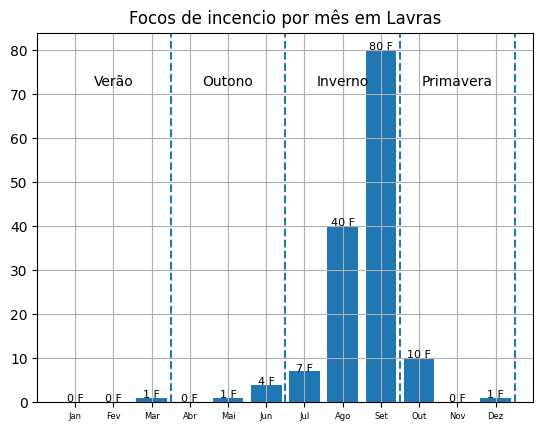

In [21]:
municipio = input().upper()
listaMunicipios = list(dataMunicipiosMG["Municipio"].unique())

if municipio in listaMunicipios:

    dfMunicipio = focos_mes_municipio(municipio, "../data/processed/focos_mg_ref_2015-2025.csv")

    plt.Figure(figsize=(18,9))
    plt.title(f"Focos de incencio por mês em {municipio.capitalize()}")
    plt.bar(dfMunicipio["mes"], dfMunicipio["Focos"])
    plt.grid(True)
    plt.xticks(fontsize = 6)
    for mes, value in zip(dfMunicipio["mes"], dfMunicipio["Focos"]):
        plt.text(mes, value, f"{value} F", fontsize=8, ha="center")
    
    plt.axvline(x=2.5, linestyle='--')  
    plt.axvline(x=5.5, linestyle='--')  
    plt.axvline(x=8.5, linestyle='--')  
    plt.axvline(x=11.5, linestyle='--') 

    plt.text(1, max(dfMunicipio["Focos"])*0.9, "Verão", ha='center')
    plt.text(4, max(dfMunicipio["Focos"])*0.9, "Outono", ha='center')
    plt.text(7, max(dfMunicipio["Focos"])*0.9, "Inverno", ha='center')
    plt.text(10, max(dfMunicipio["Focos"])*0.9, "Primavera", ha='center')
    plt.show()

In [47]:
PATH1 = "../data/processed/focos_mg_ref_2015-2025.csv"
PATH2 = "../data/processed/focos_mg_municipios_ref_2015-2025.csv"

df = pd.read_csv(PATH1, sep = ",", index_col=0)
data_municipios = pd.read_csv(PATH2, sep=",", index_col=0)



coords = df.groupby("municipio")[["lat", "lon"]].mean().reset_index()

data_municipios = data_municipios.merge(coords, left_on="Municipio", right_on="municipio", how="left")
data_municipios = data_municipios.drop(["municipio"], axis=1)

data_municipios.to_csv(PATH2, sep=",")
data_municipios.head()

,Municipio,Numero_Focos,lat,lon
0,PARACATU,1727,-17.253227,-46.881372
1,JOÃO PINHEIRO,1383,-17.567416,-45.995193
2,LASSANCE,1342,-17.835112,-44.505908
3,UBERABA,1267,-19.672502,-47.959500
4,UNAÍ,1103,-16.407472,-46.808528


CRIAÇÃO DO MAPA DE CALOR

In [49]:
mapa = fl.Map(location=[-19.0, -44.0], zoom_start=6.5)
data = list(zip(data_municipios.lat, data_municipios.lon, data_municipios.Numero_Focos))
heatMap = HeatMap(data, radius=20, blur=20)
mapa.add_child(heatMap)
mapa.save("../maps/HeatMapMG.html")